In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Simulation 1

In [2]:
# read simulation 1 data
df = pd.read_csv("../data/simulations/simulation1_all_WISER.csv")
mapping_dict = {"gumbel": "Gumbel", "inverse": "Inverse", "redgreen": "Red-Green", "pf": "Permute-and-Flip"}
df['watermark_type'] = df['watermark_type'].map(mapping_dict)
df.head()


,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time_lower,time_upper,khat_over,khat_under,khat_exact,vocab_size,output_tokens,watermark_type,seed,ar_coeff
0,simulation 1,0.968968,0.97600,0.915952,0.996016,0.986250,1.0000,0.993077,0.971460,0.979808,...,0.000047,0.000198,0.0275,0.0000,0.9725,1000,500,Gumbel,1234,0.1
1,simulation 1,0.898420,0.91573,0.733318,0.988048,0.832458,1.0000,0.908570,0.911402,0.924878,...,0.000047,0.000209,0.3215,0.0000,0.6785,1000,500,Inverse,1234,0.1
2,simulation 1,0.245201,0.28800,0.000000,0.720000,0.522083,0.5885,0.553306,0.590483,0.622758,...,0.000025,0.000213,0.1305,0.4115,0.4580,1000,500,Red-Green,1234,0.1
3,simulation 1,0.941182,0.96000,0.808000,0.988000,0.787000,1.0000,0.880806,0.922681,0.957900,...,0.000048,0.000226,0.4195,0.0000,0.5805,1000,500,Permute-and-Flip,1234,0.1
4,simulation 1,0.980534,0.98800,0.932000,0.996016,0.999500,1.0000,0.999750,0.983396,0.990437,...,0.000047,0.000187,0.0010,0.0000,0.9990,1000,500,Gumbel,1234,0.2


<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_1761/3478156900.py:37: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel(f"$\phi$", fontsize=14, labelpad=10)


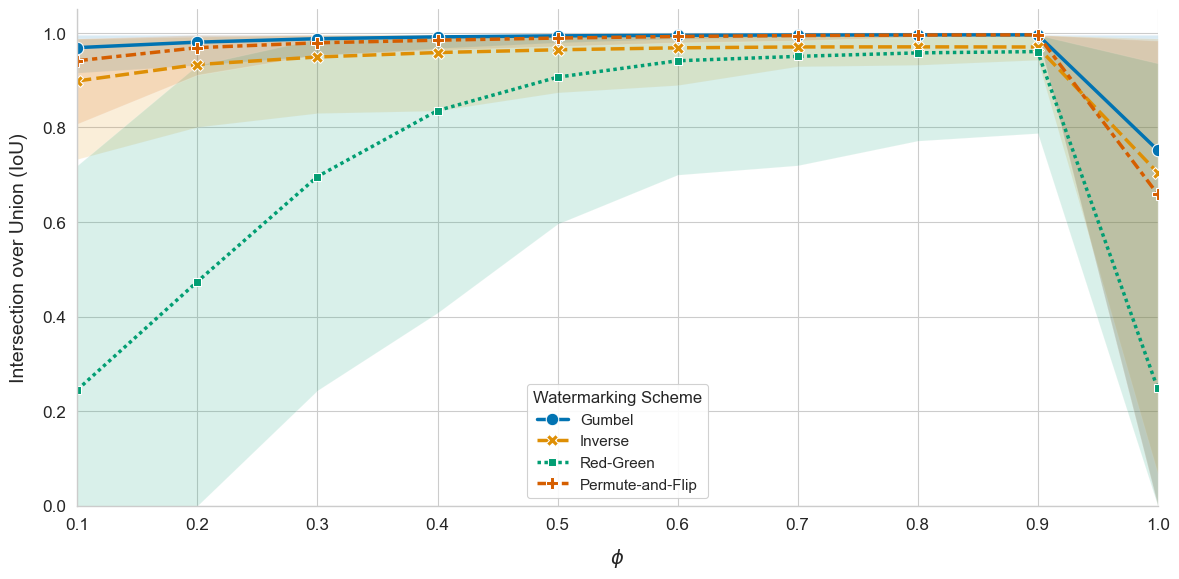

In [5]:
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

# color friendly pallete
unique_methods = df['watermark_type'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_methods))
method_colors = dict(zip(unique_methods, palette))

# create confidence bands
for method in unique_methods:
    subset = df[df['watermark_type'] == method].sort_values('ar_coeff')
    plt.fill_between(
        subset['ar_coeff'],
        subset['iou_lower'],
        subset['iou_upper'],
        color=method_colors[method],
        alpha=0.15, # Transparency for the bands
        edgecolor=None # No border on the band
    )

# main lineplot
sns.lineplot(
    data=df,
    x='ar_coeff',
    y='iou',
    hue='watermark_type',
    style='watermark_type',
    palette=method_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# Labeling
plt.xlabel(f"$\phi$", fontsize=14, labelpad=10)
plt.ylabel("Intersection over Union (IoU)", fontsize=14, labelpad=10)

# Axis customization
plt.ylim(0, 1.05)
plt.xlim(df['ar_coeff'].min(), df['ar_coeff'].max())

# Customize the legend
# moving it outside or to a "best" location
plt.legend(title='Watermarking Scheme', title_fontsize=12, fontsize=11, loc='best', frameon=True, framealpha=0.9)

# Remove top and right spines for a cleaner "academic" look
sns.despine()
plt.tight_layout()
plt.show()

## Simulation 2 (Delta + n)

In [22]:
# read simulation 3 data
df = pd.read_csv("../data/simulations/simulation2_all_WISER.csv")
df['delta'] = df['delta'].astype(str)
df

,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time_lower,time_upper,khat_over,khat_under,khat_exact,vocab_size,output_tokens,watermark_type,seed,delta
0,simulation 2,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,NaN,0.327877,0.327877,...,0.000011,0.000024,0.00,1.00,0.00,1000,64,partial,1234,1.5
1,simulation 2,0.017021,0.000000,0.000000,0.000000,0.020000,0.02,0.020000,0.339712,0.327877,...,0.000011,0.000071,0.00,0.98,0.02,1000,64,partial,1234,2.0
2,simulation 2,0.045396,0.000000,0.000000,0.683000,0.070000,0.07,0.070000,0.362550,0.327877,...,0.000012,0.000058,0.00,0.93,0.07,1000,64,partial,1234,2.5
3,simulation 2,0.130650,0.000000,0.000000,0.849145,0.170000,0.17,0.170000,0.421830,0.327877,...,0.000012,0.000068,0.00,0.83,0.17,1000,64,partial,1234,3.0
4,simulation 2,0.289203,0.000000,0.000000,0.944623,0.350000,0.35,0.350000,0.530466,0.327877,...,0.000013,0.000079,0.00,0.65,0.35,1000,64,partial,1234,3.5
5,simulation 2,0.012992,0.000000,0.000000,0.159375,0.030000,0.03,0.030000,0.347286,0.334523,...,0.000012,0.000115,0.00,0.97,0.03,1000,128,partial,1234,1.5
6,simulation 2,0.043850,0.000000,0.000000,0.628431,0.080000,0.08,0.080000,0.371662,0.334523,...,0.000014,0.000079,0.00,0.92,0.08,1000,128,partial,1234,2.0
7,simulation 2,0.100413,0.000000,0.000000,0.755392,0.160000,0.16,0.160000,0.413968,0.334523,...,0.000013,0.000086,0.00,0.84,0.16,1000,128,partial,1234,2.5
8,simulation 2,0.310156,0.000000,0.000000,0.925936,0.440000,0.44,0.440000,0.566702,0.334523,...,0.000014,0.000103,0.00,0.56,0.44,1000,128,partial,1234,3.0
9,simulation 2,0.610495,0.730670,0.000000,0.971078,0.770000,0.79,0.779872,0.768383,0.856176,...,0.000018,0.000132,0.04,0.21,0.75,1000,128,partial,1234,3.5


<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_1761/183299266.py:43: SyntaxWarning: invalid escape sequence '\d'
  plt.legend(title=f"$\delta$", title_fontsize=12, fontsize=11, loc='best', frameon=True, framealpha=0.9)


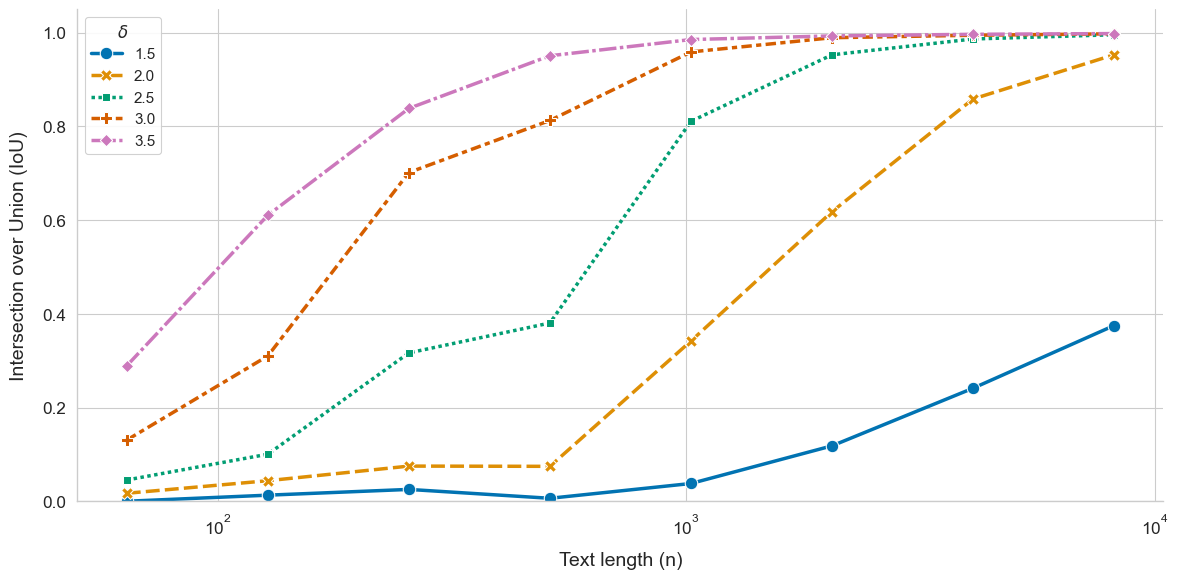

In [23]:
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

# color friendly pallete
unique_deltas = df['delta'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_deltas))
delta_colors = dict(zip(unique_deltas, palette))

# # create confidence bands
# for delta in delta_colors:
#     subset = df[df['delta'] == delta].sort_values('output_tokens')
#     plt.fill_between(
#         subset['output_tokens'],
#         subset['iou_lower'],
#         subset['iou_upper'],
#         color=delta_colors[delta],
#         alpha=0.15, # Transparency for the bands
#         edgecolor=None # No border on the band
#     )

# main lineplot
sns.lineplot(
    data=df,
    x='output_tokens',
    y='iou',
    hue='delta',
    style='delta',
    palette=delta_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# Labeling and axis
plt.xlabel(f"Text length (n)", fontsize=14, labelpad=10)
plt.ylabel("Intersection over Union (IoU)", fontsize=14, labelpad=10)
plt.ylim(0, 1.05)
plt.xscale('log')

# Customize the legend
# moving it outside or to a "best" location
plt.legend(title=f"$\delta$", title_fontsize=12, fontsize=11, loc='best', frameon=True, framealpha=0.9)

# Remove top and right spines for a cleaner "academic" look
sns.despine()
plt.tight_layout()
plt.show()

## Simulation 3 (Gap)

In [14]:
# read simulation 3 data
df = pd.read_csv("../data/simulations/simulation3_all_WISER.csv")
mapping_dict = {"gumbel": "Gumbel", "inverse": "Inverse", "redgreen": "Red-Green", "pf": "Permute-and-Flip"}
df['watermark_type'] = df['watermark_type'].map(mapping_dict)
df.head()

,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time_lower,time_upper,khat_over,khat_under,khat_exact,vocab_size,output_tokens,watermark_type,seed,gap
0,simulation 2,0.919249,0.931464,0.840577,0.937500,0.999833,0.369333,0.539411,0.929541,0.926849,...,0.000074,0.000278,0.0,0.9970,0.0030,1000,1000,Gumbel,1234,10
1,simulation 2,0.000468,0.000000,0.000000,0.000000,0.001500,0.000500,0.000750,0.261491,0.260661,...,0.000022,0.000101,0.0,1.0000,0.0000,1000,1000,Inverse,1234,10
2,simulation 2,0.251134,0.296667,0.000000,0.752478,0.589500,0.247667,0.348794,0.613914,0.815410,...,0.000034,0.000257,0.0,0.9930,0.0070,1000,1000,Red-Green,1234,10
3,simulation 2,0.674142,0.681250,0.316667,0.912500,0.999333,0.630167,0.772932,0.946720,0.960109,...,0.000086,0.000342,0.0,0.9720,0.0280,1000,1000,Permute-and-Flip,1234,10
4,simulation 2,0.868963,0.870588,0.810468,0.916409,0.999833,0.674667,0.805678,0.956484,0.964991,...,0.000079,0.000337,0.0,0.7485,0.2515,1000,1000,Gumbel,1234,20


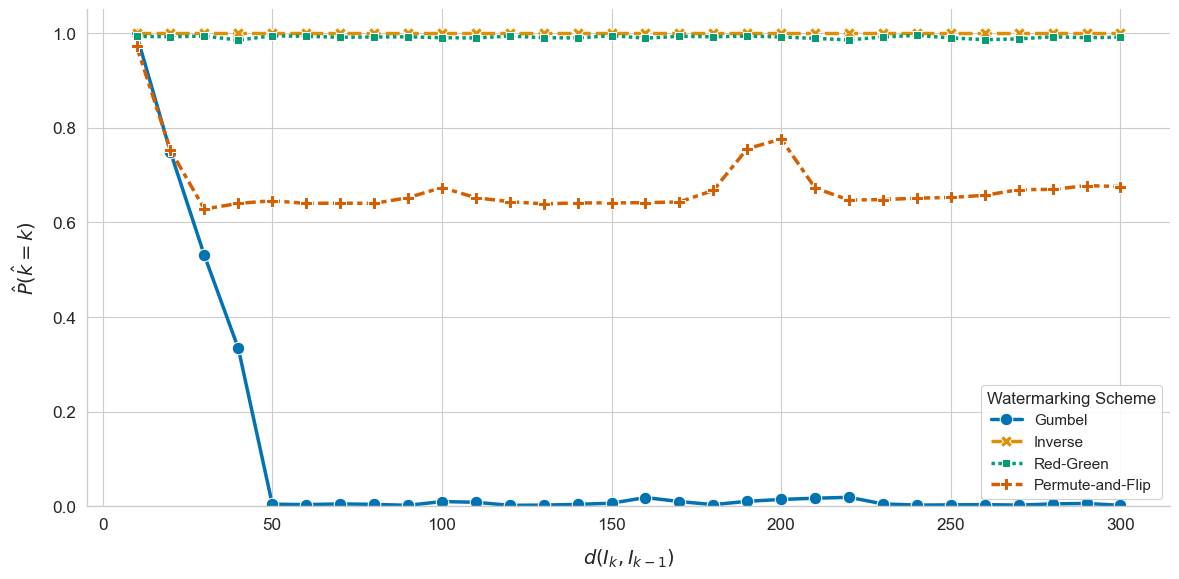

In [17]:
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

# color friendly pallete
unique_methods = df['watermark_type'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_methods))
method_colors = dict(zip(unique_methods, palette))

# main lineplot
sns.lineplot(
    data=df,
    x='gap',
    y='khat_under',
    hue='watermark_type',
    style='watermark_type',
    palette=method_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# labeling
plt.ylim(0, 1.05)
plt.xlabel(r"$d(I_k, I_{k-1})$", fontsize=14, labelpad=10)
plt.ylabel(r"$\hat{P}(\hat{k} = k)$", fontsize=14, labelpad=10)
plt.legend(title="Watermarking Scheme", title_fontsize=12, fontsize=11, loc='best', frameon=True, framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.show()